In [83]:
# necessary imports
import numpy as np
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import stats
from scipy.stats import norm
from IPython.display import Image
%matplotlib inline
import glob
import re
import os
from datetime import datetime
import math

Let's redo all our centroid calculations, just for clarity.

First, make the position matrices and write our centroid function.

In [10]:
positionx = np.zeros_like(imagedata, dtype=np.int32)   
j = 0 # start at origin
k = 0
for i in range(int(3840)):
    positionx[:,int(j)] = k
    k+=1
    j+=1
    
positiony = np.zeros_like(imagedata, dtype=np.int32)   
j = 0 # start at origin
k = 0
for i in range(int(2160)):
    positiony[int(j),:] = k
    k+=1
    j+=1

In [11]:
def centroid(images):
    for image in images:
        imagedata = fits.getdata(image)

        mask = imagedata<250
        imagedata[mask] = 0

        x_mul = imagedata*positionx
        sum_xmul = np.sum(x_mul)
        weight_x = sum_xmul/(np.sum(imagedata))

        y_mul = imagedata*positiony
        sum_ymul = np.sum(y_mul)
        weight_y = sum_ymul/(np.sum(imagedata))

        cenX.append(weight_x)
        cenY.append(weight_y)

Next, draw out the images and find their times.

In [99]:
allimagepath = "/Users/ashleyashiku/Desktop/PULSE-A/operation/*.fits"
imagelog = glob.glob(allimagepath)

# using Rodrigo's code here
def natural_sort_key(filename):
    """
    Extracts the first sequence of digits and converts it to an integer 
    for numerical sorting.
    """
    # Find all sequences of digits in the string
    digits = re.findall(r'\d+', filename)
    if digits:
        return (0, int(digits[0]))   # numeric sort first
    return (1, filename)  

def get_file_timestamps(filename):
    folder_path = ""
    modification_time = os.path.getmtime(folder_path+'/'+filename)
    return (modification_time)

# Sort the list using the custom key
filenames=sorted(imagelog,key=natural_sort_key)

allimagepath2 = "/Users/ashleyashiku/Desktop/PULSE-A/oldoperation/*.fits"
imagelog2 = glob.glob(allimagepath2)

filenames2=sorted(imagelog2,key=natural_sort_key)

In [106]:
operation_time = []
for imager in filenames2:
    opT = get_file_timestamps(imager)
    operation_time.append(opT)
    
resi_time = np.array(operation_time) - operation_time[0]
print(resi_time)

[  0.           0.32646489   0.64596415   0.96994877   1.28819227
   1.60078144   1.9175396    2.23297763   2.55994558   2.88964343
   3.22098184   3.54231334   3.87049031   4.18674588   4.51398134
   4.84119487   5.16120982   5.48587584   5.80860806   6.13072777
   6.45597315   6.78215122   7.10329747   7.4212513    7.74386978
   8.06046057   8.39058614   8.71691442   9.03685284   9.36525965
   9.68434262  10.00927353  10.33118224  10.64941478  10.97936726
  11.30776596  11.63604236  11.95453238  12.27976775  12.60901785
  12.93406773  13.27827835  13.59468651  13.9180851   14.23690796
  14.55563331  14.87456536  15.20391035  15.52726054  15.85162115
 199.86602545]


In [86]:
timestamps = []
for image in filenames:
    opT = get_file_timestamps(image)
    timestamps.append(opT)
    
# make relative time
startT = timestamps[0]
timestamps = np.array(timestamps)
timeRel = timestamps - startT

dt = datetime.strptime("Nov 14 8:07pm", "%b %d %I:%M%p")
unix = dt.timestamp()
print(unix)

-2181505980.0


Here, I'm actually computing the centroids again. They come out in two separate lists.

I'm going to draw out the centroid that I'm actually working with for helloworld414.

In [20]:
cenX = []
cenY = []
centroid(filenames)

In [21]:
cenZip = zip(cenX, cenY)
cenZip = list(cenZip)
cenZip = np.array(cenZip)

In [33]:
cen414 = cenZip[415]
print(cen414)

[1402.94579934  897.26341301]


In [57]:
# now, we define the x axis vector
center = cen414
xaxis = np.array([1458, 897.26341])
azi = np.array([1433.7599, 841.27788])

The first thing I'm going to do is load the image I'm working with, helloworld414.fits and plot this centroid.

[]

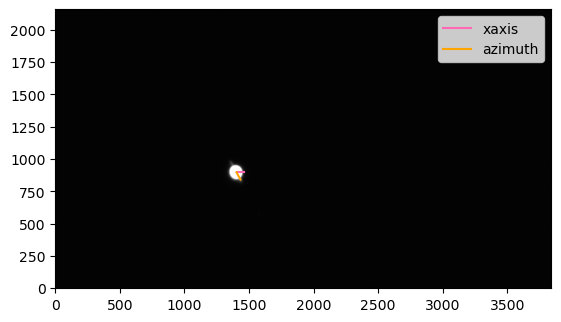

In [44]:
image = fits.open('/Users/ashleyashiku/Desktop/PULSE-A/operation/helloworld414.fits')

header = image[0].header
imagedata = image[0].data

plt.imshow(imagedata, cmap = "gray", origin = "lower")
plt.plot( (cen414[0], xaxis[0]), (cen414[1], xaxis[1]), color = "hotpink", label = "xaxis")
plt.plot( (cen414[0], azi[0]), (cen414[1], azi[1]), color = "orange", label = "azimuth")
plt.legend()
#plt.scatter(cen414[0], cen414[1])

plt.plot()

Nice! Now, let's compute this rotation angle between these two vectors. We have to convert these two points into vectors by subtracting the centerpoint.

In [61]:
def angle(x, y):
    dotpro = np.sum(x*y)
    lenx = np.sqrt(np.sum(x**2))
    leny = np.sqrt(np.sum(y**2))
    
    work = dotpro/(lenx*leny)
    angle_radians = math.acos(work)
    angle_degrees = math.degrees(angle_radians)
    return math.degrees(angle_radians)

def rotation(angle, x):
    # turn from degrees to radians
    angle_rad = -math.radians(angle)

    rotMat = np.array([[math.cos(angle_rad), -math.sin(angle_rad)], 
                  [math.sin(angle_rad), math.cos(angle_rad)]])
    
    # rotate vector x
    return rotMat@x

In [60]:
offsetDeg = angle(xaxis-center, azi-center)
print(offsetDeg)

61.171874937426146


In [62]:
cenXrot = []
cenYrot = []

for i in cenZip:
    conv = rotation(offsetDeg, i)
    cenXrot.append(conv[0])
    cenYrot.append(conv[1])

Normalize with respect to first and put into arcseconds.

In [65]:
plate_scale=17.9/(47.5*2)

firstRotX, firstRotY = cenXrot[0], cenYrot[0]
cenXedit = cenXrot - firstRotX
cenYedit = cenYrot - firstRotY

cenXarc = cenXedit*plate_scale
cenYarc = cenYedit*plate_scale

In [68]:
def rms(data):

    root = np.sqrt(np.mean(data**2))

    return root

In [71]:
azRoot = rms(cenXarc)
alRoot = rms(cenYarc)

print(f"Az RMS error: {azRoot:.2f} arcsec")
print(f"Al RMS error: {alRoot:.2f} arcsec")

Az RMS error: 16.06 arcsec
Al RMS error: 89.91 arcsec


This is kind of confusing. Let's replot this.

[]

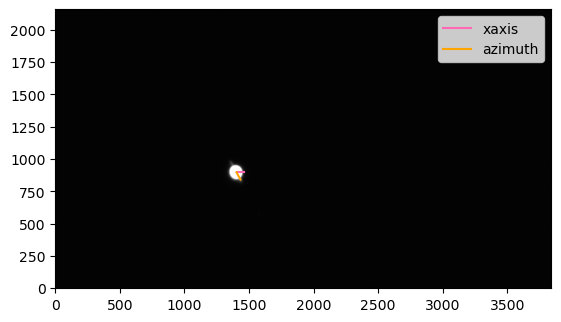

In [72]:
image = fits.open('/Users/ashleyashiku/Desktop/PULSE-A/operation/helloworld414.fits')

header = image[0].header
imagedata = image[0].data

plt.imshow(imagedata, cmap = "gray", origin = "lower")
plt.plot( (cen414[0], xaxis[0]), (cen414[1], xaxis[1]), color = "hotpink", label = "xaxis")
plt.plot( (cen414[0], azi[0]), (cen414[1], azi[1]), color = "orange", label = "azimuth")
plt.legend()
#plt.scatter(cen414[0], cen414[1])

plt.plot()

Well, let's just plot it out. 

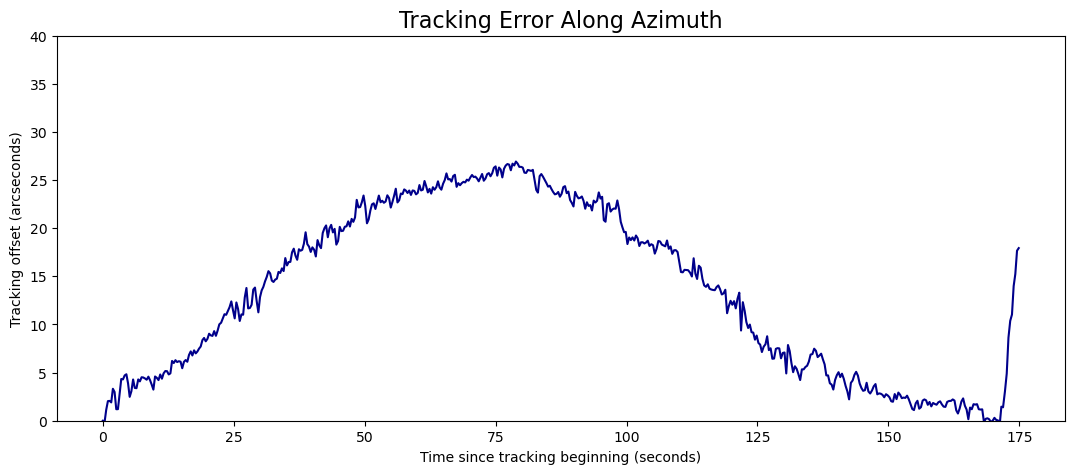

In [91]:
fig, ax = plt.subplots(figsize=(13, 5))   
ax.plot(timeRel, cenXarc, color = "darkblue")  
ax.set_xlabel('Time since tracking beginning (seconds)')
ax.set_ylabel('Tracking offset (arcseconds)')
ax.set_title('Tracking Error Along Azimuth', fontsize=16)
ax.set_ylim(0,40)
plt.show() 

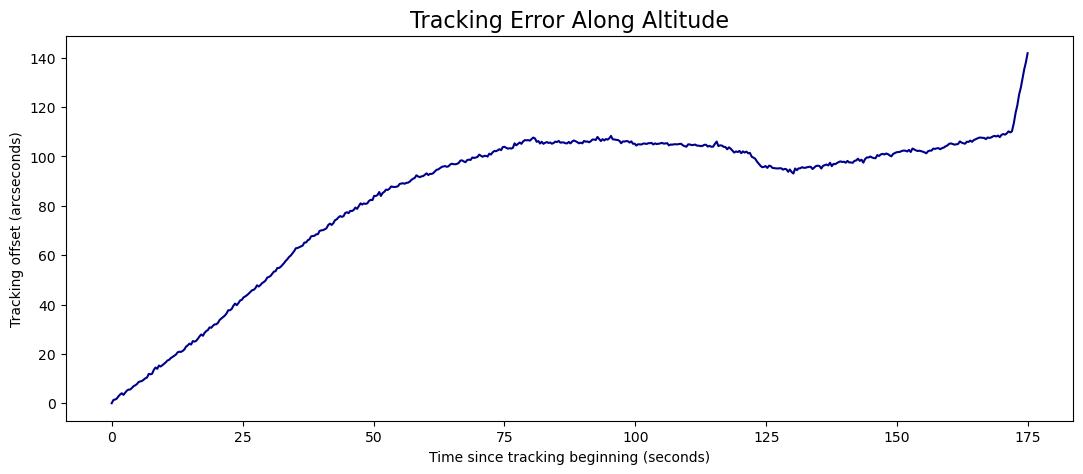

In [78]:
fig, ax = plt.subplots(figsize=(13, 5))   
ax.plot(timeRel, cenYarc, color = "darkblue")  
ax.set_xlabel('Time since tracking beginning (seconds)')
ax.set_ylabel('Tracking offset (arcseconds)')
ax.set_title('Tracking Error Along Altitude', fontsize=16)
plt.show() 